In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv


SEGMENT CUSTOMERS INTO GROUPS BASED ON :

* ANNUAL INCOME
* SPENDING SCORE
* AGE


VISUALIZATION SEABORN AND MATPLOTLIB

LIBRARIES REQUIRED

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score


In [3]:
df = pd.read_csv("/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


SHAPE OF DATASET

In [4]:
df.shape

(200, 5)

COLUMN LIST

In [5]:
df.columns.tolist()

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

ALL ABOUT DATASET

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


FIRST 5 ROWS

In [7]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


CHECKING FOR NULL

In [8]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

NUMERICAL FEATURES

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


SELECTING FEATURES

In [11]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

display(X.head())
display(X.describe())

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


VISUALIZATION

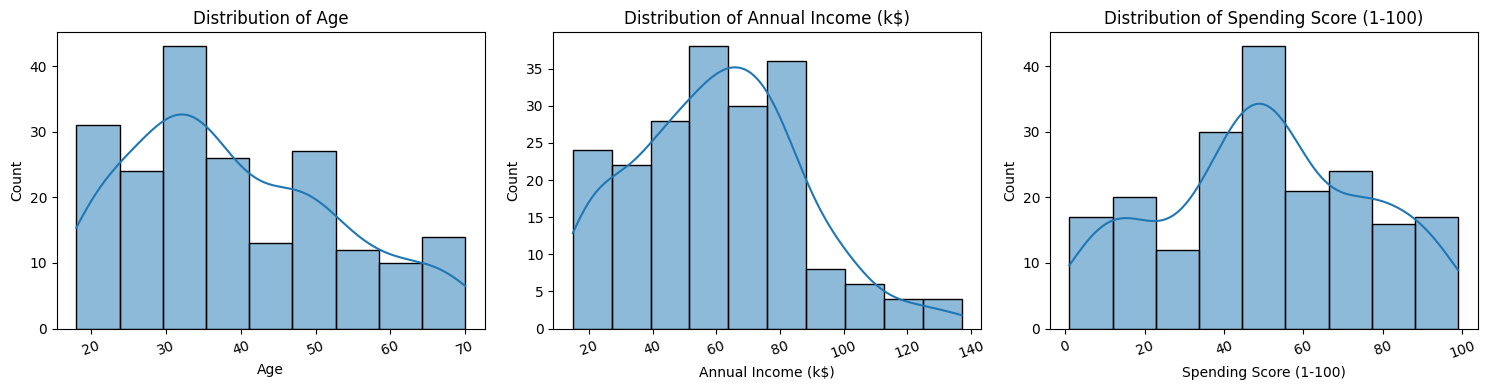

In [12]:
plt.figure(figsize=(15, 4))

for i, column in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=X, x=column, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

RELATIONSHIP BETWEEN FEATURES

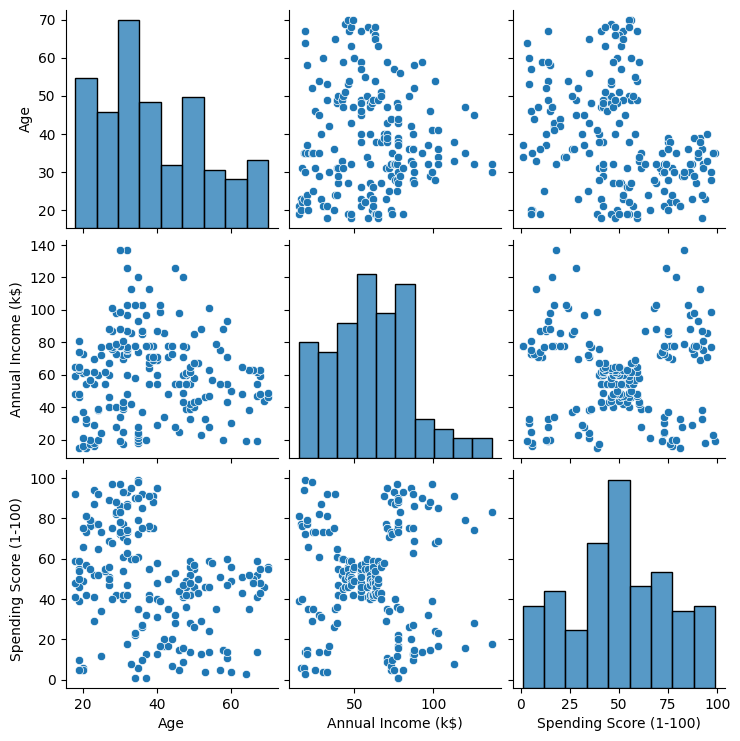

In [13]:
sns.pairplot(X, diag_kind='hist')
plt.show()

CORELATIONS

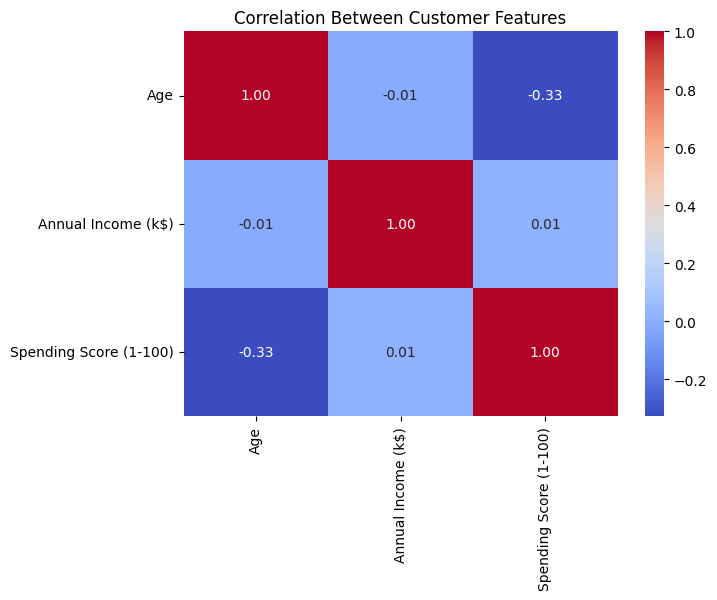

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Customer Features')
plt.show()

STANDARIZATION

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=X.index
)

display(X_scaled.head())

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


CHECKING AGAIN

In [16]:

# Check the mean and standard deviation after scaling

print("Feature means:")
print(X_scaled.mean().round(3))

print("\nFeature standard deviations:")
print(X_scaled.std(ddof=0).round(3))

Feature means:
Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

Feature standard deviations:
Age                       1.0
Annual Income (k$)        1.0
Spending Score (1-100)    1.0
dtype: float64


FINAL COMPARISON USING VISUALIZATION

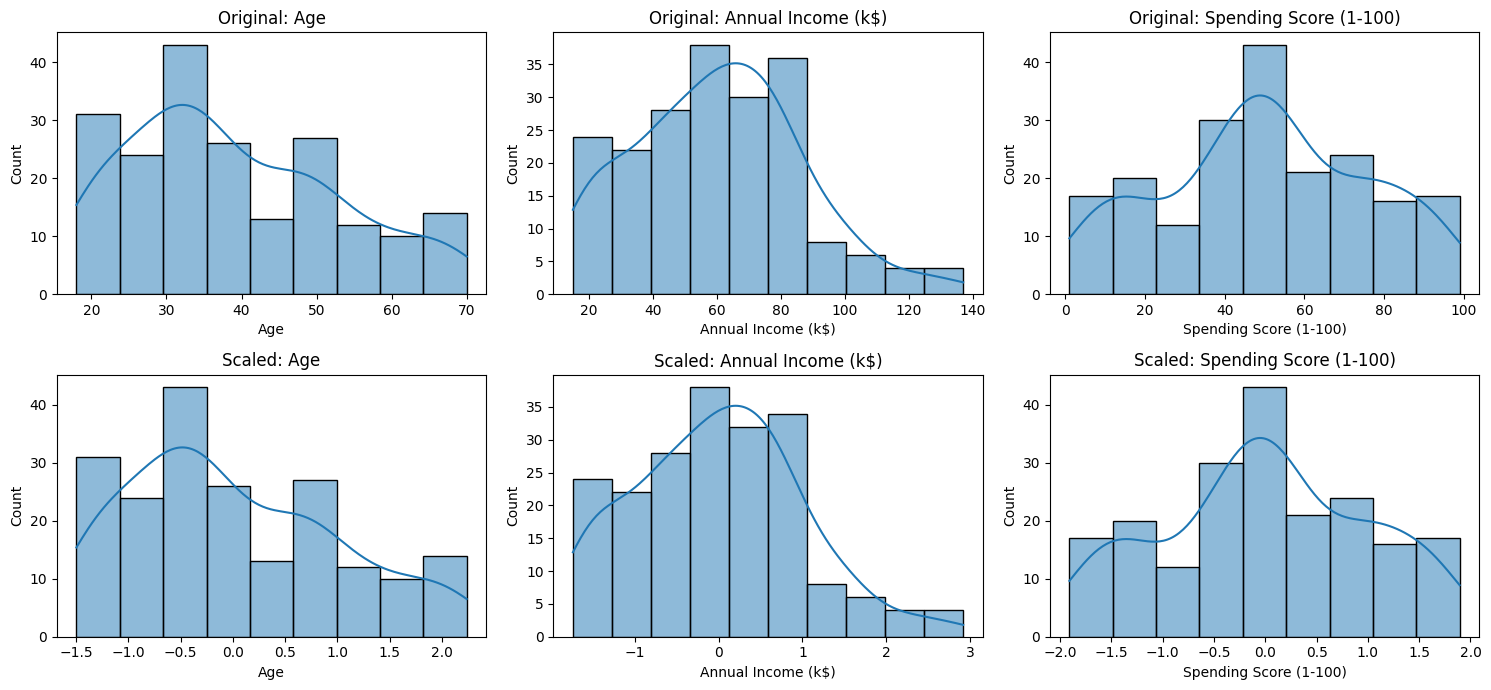

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, column in enumerate(features):
    sns.histplot(X[column], ax=axes[0, i], kde=True)
    axes[0, i].set_title(f'Original: {column}')

    sns.histplot(X_scaled[column], ax=axes[1, i], kde=True)
    axes[1, i].set_title(f'Scaled: {column}')

plt.tight_layout()
plt.show()

ELBOW PLOT

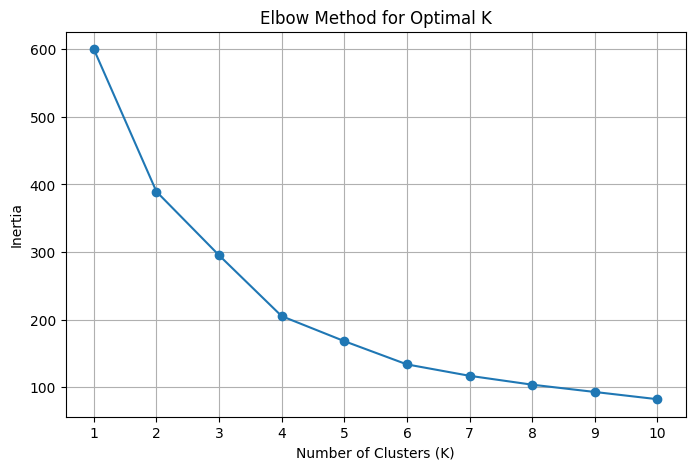

In [18]:
inertia_values = []

K_values = range(1, 11)

for k in K_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_values,
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_values))
plt.grid(True)
plt.show()

SILHOUTTE SCORE TEST

K = 2, Silhouette Score = 0.3355
K = 3, Silhouette Score = 0.3578
K = 4, Silhouette Score = 0.4040
K = 5, Silhouette Score = 0.4166
K = 6, Silhouette Score = 0.4284
K = 7, Silhouette Score = 0.4172
K = 8, Silhouette Score = 0.4082
K = 9, Silhouette Score = 0.4177
K = 10, Silhouette Score = 0.4066


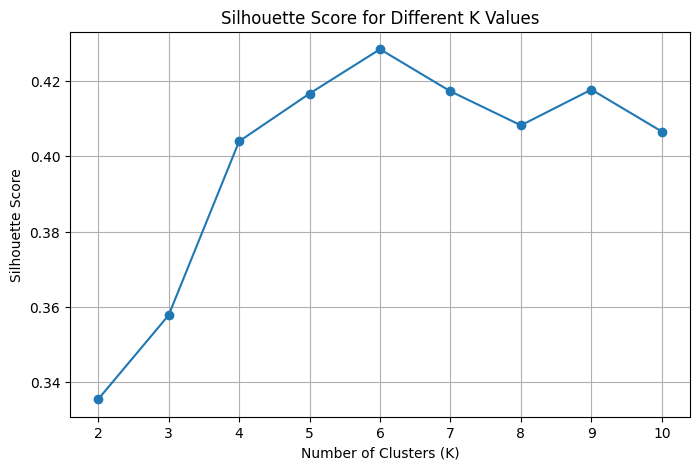

In [19]:
silhouette_values = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_values.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

MODEL FITTING

In [20]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully!")
print("Total customers:", len(cluster_labels))
print("Number of clusters:", kmeans.n_clusters)

K-Means model trained successfully!
Total customers: 200
Number of clusters: 6


ADDING CLUSTER

In [21]:

df['Cluster'] = cluster_labels
display(df.head(10))

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5
5,6,Female,22,17,76,4
6,7,Female,35,18,6,5
7,8,Female,23,18,94,4
8,9,Male,64,19,3,5
9,10,Female,30,19,72,4


CUSTOMER IN EACH CLUSTER

Customers in each cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


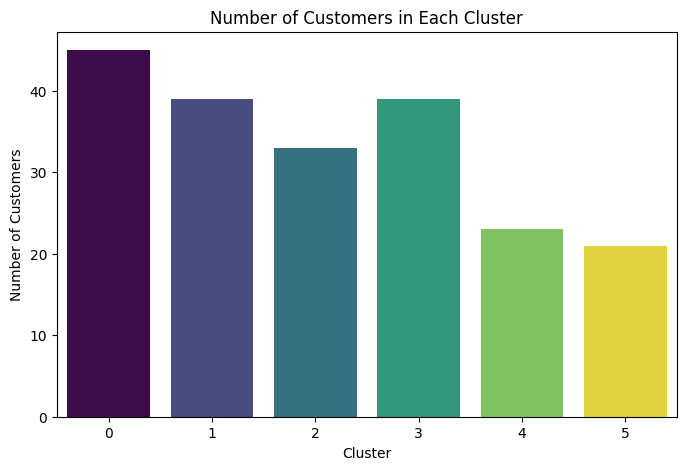

In [22]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Cluster', hue='Cluster', palette='viridis', legend=False)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

In [23]:
# CLUSTER CHARACTERSTICS EXAMINATION

In [24]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


SCATTER PLOT

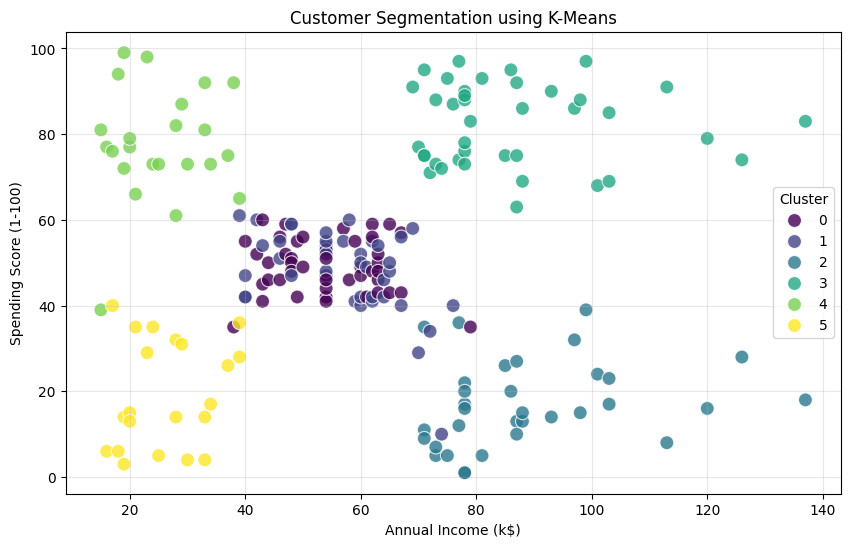

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.show()

ADDITION OF CLUSTER CENTRES

,Age,Annual Income (k$),Spending Score (1-100)
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


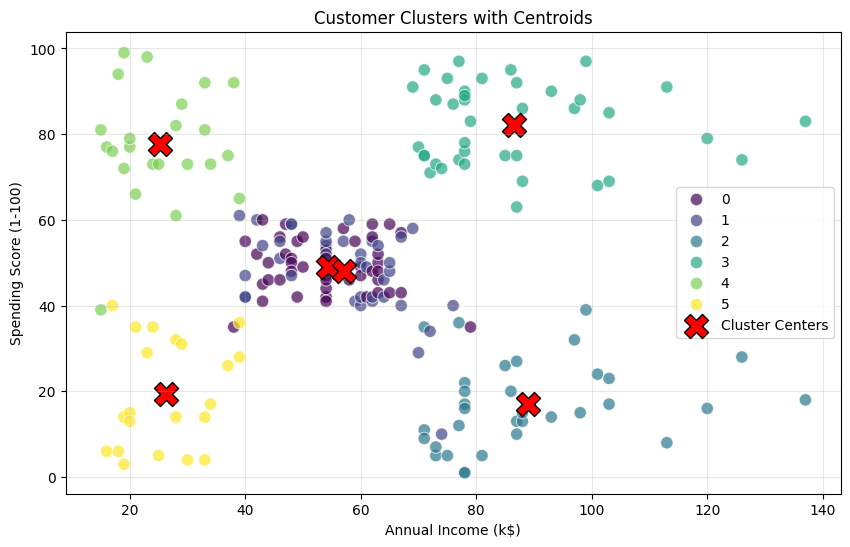

In [26]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=features
)

display(centers_df.round(2))

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=80,
    alpha=0.7
)

plt.scatter(
    centers_df['Annual Income (k$)'],
    centers_df['Spending Score (1-100)'],
    marker='X',
    s=300,
    color='red',
    edgecolor='black',
    label='Cluster Centers'
)

plt.title('Customer Clusters with Centroids')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

3-D PLOT

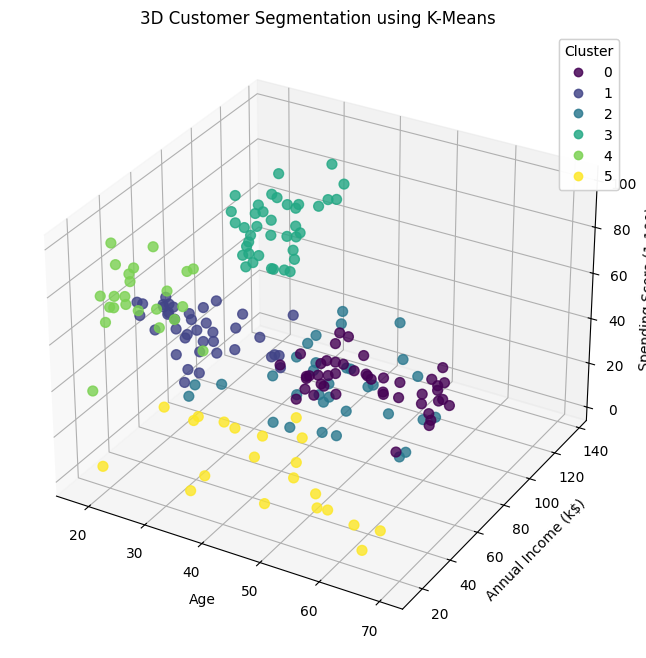

In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.8
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

ax.set_title('3D Customer Segmentation using K-Means')

legend = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend)

plt.show()

In [28]:
EVALUATION

NameError: name 'EVALUATION' is not defined

In [ ]:

from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(X_scaled, df['Cluster'])

print("Model Evaluation")
print("----------------")
print("Number of clusters:", kmeans.n_clusters)
print("Total customers:", len(df))
print("Inertia:", round(kmeans.inertia_, 2))
print("Silhouette Score:", round(final_silhouette, 4))

In [ ]:
# FINAL

In [ ]:

cluster_profile = df.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending=('Spending Score (1-100)', 'mean')
).round(2)

cluster_profile['Customer_Percentage'] = (
    cluster_profile['Customer_Count'] / len(df) * 100
).round(2)

display(cluster_profile)

NOMENCLATURE

In [ ]:
segment_names = {
    0: 'Older - Moderate Income and Spending',
    1: 'Young - Moderate Income and Spending',
    2: 'High Income - Low Spending',
    3: 'High Income - High Spending',
    4: 'Low Income - High Spending',
    5: 'Low Income - Low Spending'
}

df['Customer_Segment'] = df['Cluster'].map(segment_names)

display(
    df[['CustomerID', 'Age', 'Annual Income (k$)',
        'Spending Score (1-100)', 'Cluster', 'Customer_Segment']].head(10)
)

FINAL FINAL

In [ ]:
op = '/kaggle/working/customer_segments.csv'

df.to_csv(op, index=False)

print("Dataset exported successfully!")
print("Saved to:", op)
print("Total records:", len(df))

future use

In [ ]:

import joblib

joblib.dump(kmeans, '/kaggle/working/kmeans_model.pkl')
joblib.dump(scaler, '/kaggle/working/customer_scaler.pkl')

